In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.metrics import accuracy_score
from textblob import TextBlob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('yelp.csv')

<Axes: xlabel='stars', ylabel='count'>

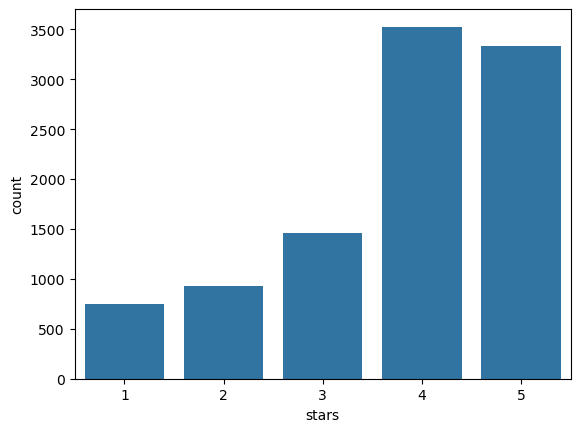

In [5]:
sns.countplot(x=df['stars'])

In [7]:
df['text']=df['text'].str.lower() # kucuk harfe cevir
df['text']=df['text'].str.replace('[^\w\s]','', regex=True) # noktolama isaretlerini kaldirir
df['text']=df['text'].str.replace('\d+','', regex=True) # rakamlari kaldirir
df['text']=df['text'].str.replace('\n','', regex=True) # satir sonlarini kaldirir
df['text']=df['text'].str.replace('\r','', regex=True) # enter lari kaldiri

In [17]:
ybw=df[(df.stars==1) | (df.stars==5)]

In [19]:
ybw = ybw.reset_index(drop=True)

In [21]:
x=ybw['text']
y=ybw[['stars']]

In [ ]:
sns.countplot(x=y['stars'])

In [27]:
d={1:0,5:1}
y.loc[:,'stars']=y['stars'].map(d)

In [ ]:
sns.countplot(x=y['stars'])

In [34]:
def ekkok(text):
    words=TextBlob(text).words
    return [word.lemmatize() for word in words]

In [ ]:
x.head()

In [ ]:
vect=CountVectorizer(stop_words='english',analyzer=ekkok, ngram_range=(1,2))
x_vect=vect.fit_transform(x).toarray()

In [44]:
x_vect.shape

(4086, 22548)

In [97]:
tf=pd.DataFrame(vect.fit_transform(x).toarray(),columns=vect.get_feature_names_out())

C:\Users\Zafer Acar\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
C:\Users\Zafer Acar\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [98]:
tf

,a,aa,aaa,aaaamazingthey,aaammmazzingits,aaron,aathis,ab,aback,abandoned,...,zuchinni,zumba,zupa,zupas,zuzu,zuzus,zwiebelkräuter,éclairs,école,ém
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4082,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4083,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4084,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
x_train, x_test, y_train, y_test = train_test_split(x_vect,y, test_size=0.2, random_state=42)

In [58]:
model=Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') #binary iki farkli sonuc varsa 0 veya 1 evet veya hayir ise sigmoid 
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.fit(x_train,y_train, batch_size=32, validation_data=(x_test,y_test),verbose=2, epochs=15)

In [64]:
model.evaluate(x_test,y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9122 - loss: 0.8522 


[0.5665901899337769, 0.9339853525161743]

In [68]:
neg=df[df['stars']==1]['text'].iloc[0]

In [103]:
len(neg)

565

In [72]:
pos=df[df['stars']==5]['text'].iloc[0]

In [87]:
text1=vect.transform([pos]).toarray()

In [109]:
text1.shape

(1, 22548)

In [89]:
p=model.predict(text1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [91]:
p

array([[1.]], dtype=float32)

In [93]:
label=['Negative','Positive']

In [95]:
label[1 if p>0.5 else 0]

'Positive'

In [113]:
model.save('sentiment.keras')

In [117]:
#pip install neattext 

In [121]:
import neattext.functions as nfx

In [ ]:
dir(nfx)

In [125]:
df.shape

(10000, 10)

In [127]:
s=' '.join(df.text)

In [132]:
from collections import Counter

In [ ]:
Counter(s.split())

In [136]:
s2=nfx.remove_stopwords(s)

In [ ]:
Counter(s2.split())

In [140]:
data=Counter(s2.split()).most_common(20)

In [144]:
data=dict(data)

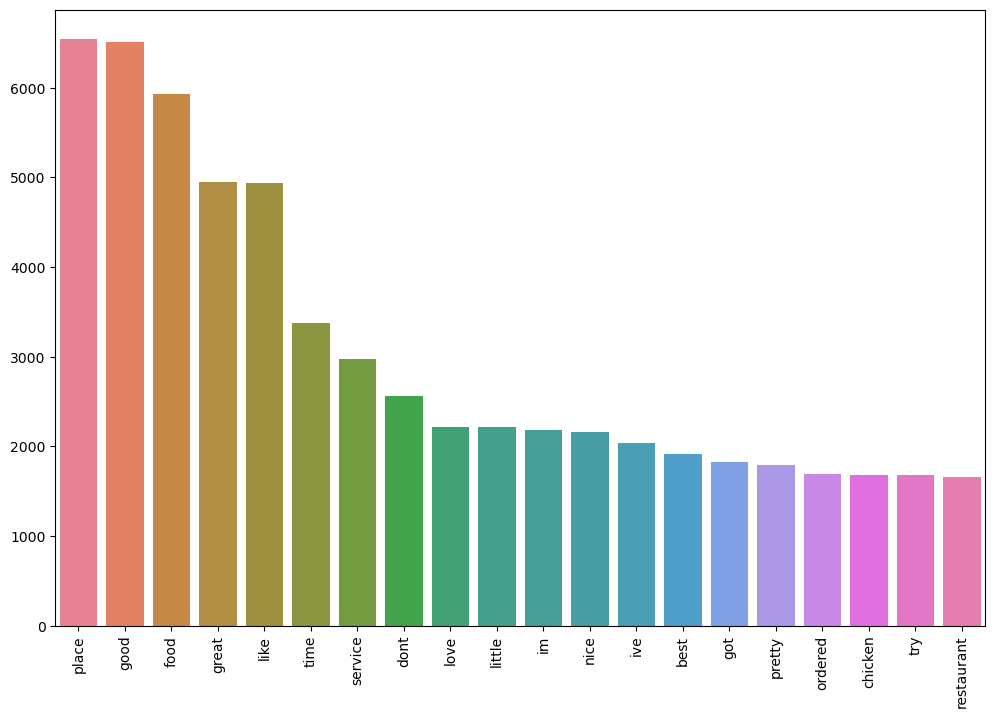

In [150]:
plt.figure(figsize=(12,8))
sns.barplot(x=data.keys(),y=data.values(),hue=data.keys())
plt.xticks(rotation=90);

In [184]:
kotu=df[df['stars']==5]

In [188]:
kotucumle=' '.join(kotu['text'])

In [190]:
kc=nfx.remove_stopwords(kotucumle)

In [ ]:
Counter(kc.split())

In [194]:
data=Counter(kc.split()).most_common(20)

In [196]:
data=dict(data)

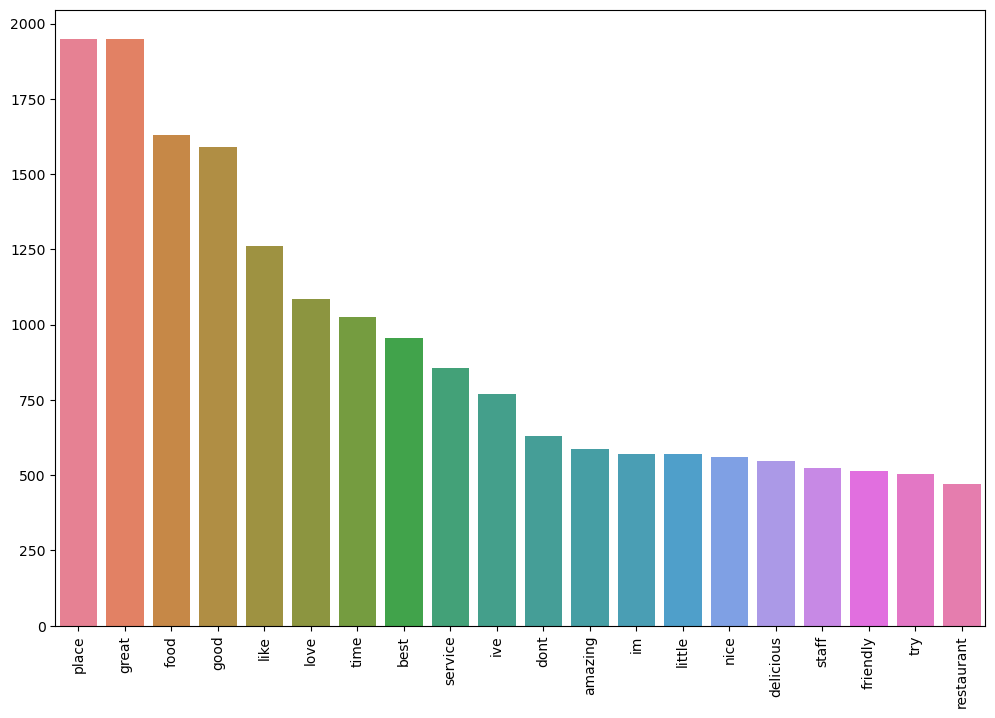

In [198]:
plt.figure(figsize=(12,8))
sns.barplot(x=data.keys(),y=data.values(),hue=data.keys())
plt.xticks(rotation=90);

In [ ]:
def label_sentiment(stars):
    if stars==1:
        return 'negative'
    elif stars==2:
        return 'negative'
    elif stars==3:
        return 'nutral'
    else:
         return 'positive'
        
        
    

In [ ]:
df['sentiment']=df['stars'].apply(label_sentiment)